# Ironhack Project Week 3

## Female Labor Force Participation in Europe: How labor market outcomes differ across countries and what factors determine these differences.

### Introduction

### Central Research Question

Why do countries with similar economic development display different female labor market outcomes? 


### Hypothesis

1. Female labor force participation (FLFP) has increased significantly over the last 20 years
2. Higher educational attainment among women is associated with higher labor force participation
3. Higher FLFP is associated with higher levels of economic development, measured by GDP per capita
4. Despite higher FLFP, a substantial gender pay gap persists across the four countries

### Variables

- Main variable:
      Female Labor Force Participation (%)

- Explanatory variables:
      Part-time Employment (%), Tertiary Educational Attainment (%), Gender Pay Gap, GDP per Capita

### Variables' Definition

- Female Labor Force Participation(%): This rate is the percentage of female labour force in relation to the comparable total population. The labour force comprises employed and unemployed persons. (Eurostat, 2026)
- Tertiary Educational Attainment (%): This rate refers to the percentage of the female population aged 25–64 who have successfully completed higher education (typically bachelor's, master's and doctoral). (Eurostat, 2026)
- Gender Pay Gap: Refers to the difference in average wages between men and women. It is calculated as the difference between the average gross hourly earnings of male and female paid employees as a percentage of average gross hourly earnings of male paid employees. (Eurostat, 2026)
- GDP per capita: Total income earned through the production of goods and services in an economic territory during an accounting period. It can be measured in three different ways: using either the expenditure approach, the income approach, or the production approach. The core indicator has been divided by the general population to achieve a per capita estimate.This indicator is expressed in current prices, meaning no adjustment has been made to account for price changes over time. This indicator is expressed in United States dollars. (World Bank, 2026)
- Part-time Employment: This rate represents the percentage of employment that is part time. Part time employment in this series is based on a common definition of less than 35 actual weekly hours worked. (World Bank, 2026)

### Data Sources
- Eurostat
- OECD
- World Bank

### Data Loading - FLFP

In [1]:
import pandas as pd
flfp_df = pd.read_csv("data/raw/labor-force.csv")

In [2]:
flfp_df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indic_em,Employment indicator,sex,Sex,age,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:LFSI_EMP_A(1.0),Employment and labour force by sex and age - a...,A,Annual,ACT,Persons in the labour force,F,Females,Y20-64,...,AT,Austria,2009,NaN,71.7,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:LFSI_EMP_A(1.0),Employment and labour force by sex and age - a...,A,Annual,ACT,Persons in the labour force,F,Females,Y20-64,...,AT,Austria,2010,NaN,72.1,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:LFSI_EMP_A(1.0),Employment and labour force by sex and age - a...,A,Annual,ACT,Persons in the labour force,F,Females,Y20-64,...,AT,Austria,2011,NaN,72.4,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:LFSI_EMP_A(1.0),Employment and labour force by sex and age - a...,A,Annual,ACT,Persons in the labour force,F,Females,Y20-64,...,AT,Austria,2012,NaN,73.1,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:LFSI_EMP_A(1.0),Employment and labour force by sex and age - a...,A,Annual,ACT,Persons in the labour force,F,Females,Y20-64,...,AT,Austria,2013,NaN,73.9,NaN,NaN,NaN,NaN,NaN


### Data Cleaning - FLFP

In [3]:
flfp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7620 entries, 0 to 7619
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               7620 non-null   object 
 1   STRUCTURE_ID                            7620 non-null   object 
 2   STRUCTURE_NAME                          7620 non-null   object 
 3   freq                                    7620 non-null   object 
 4   Time frequency                          7620 non-null   object 
 5   indic_em                                7620 non-null   object 
 6   Employment indicator                    7620 non-null   object 
 7   sex                                     7620 non-null   object 
 8   Sex                                     7620 non-null   object 
 9   age                                     7620 non-null   object 
 10  Age class                               7620 non-null   obje

In [4]:
flfp_df.isnull().sum()

STRUCTURE                                    0
STRUCTURE_ID                                 0
STRUCTURE_NAME                               0
freq                                         0
Time frequency                               0
indic_em                                     0
Employment indicator                         0
sex                                          0
Sex                                          0
age                                          0
Age class                                    0
unit                                         0
Unit of measure                              0
geo                                          0
Geopolitical entity (reporting)              0
TIME_PERIOD                                  0
Time                                      7620
OBS_VALUE                                    0
Observation value                         7620
OBS_FLAG                                  7212
Observation status (Flag) V2 structure    7212
CONF_STATUS  

In [8]:
flfp_df["sex"].value_counts()

sex
F    2540
M    2540
T    2540
Name: count, dtype: int64

In [9]:
flfp_df["Sex"].value_counts()

Sex
Females    2540
Males      2540
Total      2540
Name: count, dtype: int64

In [12]:
flfp_df["Geopolitical entity (reporting)"].value_counts()

Geopolitical entity (reporting)
France                                       276
Sweden                                       252
Cyprus                                       204
Bulgaria                                     204
Austria                                      204
Belgium                                      204
Italy                                        204
Lithuania                                    204
Denmark                                      204
Czechia                                      204
Euro area – 21 countries (from 2026)         204
Estonia                                      204
Greece                                       204
Germany                                      204
Spain                                        204
European Union - 27 countries (from 2020)    204
Finland                                      204
Croatia                                      204
Hungary                                      204
Ireland                              

In [11]:
flfp_df["geo"].unique()

array(['AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EA20',
       'EA21', 'EE', 'EL', 'ES', 'EU27_2020', 'FI', 'FR', 'HR', 'HU',
       'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 'ME', 'MK', 'MT', 'NL', 'NO',
       'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'TR'], dtype=object)

In [13]:
#create a file copy
flfp_clean = flfp_df.copy()

In [14]:
#filter observations
flfp_clean = flfp_clean[flfp_clean["Sex"] == "Females"]

In [15]:
flfp_clean["Sex"].value_counts()

Sex
Females    2540
Name: count, dtype: int64

In [16]:
countries = ["DE", "NL", "ES", "PT"]
flfp_clean = flfp_clean[flfp_clean["geo"].isin(countries)]

In [17]:
flfp_clean["geo"].value_counts()

geo
DE    68
ES    68
NL    68
PT    68
Name: count, dtype: int64

In [29]:
flfp_clean.nunique()

STRUCTURE                                  1
STRUCTURE_ID                               1
STRUCTURE_NAME                             1
freq                                       1
Time frequency                             1
indic_em                                   1
Employment indicator                       1
sex                                        1
Sex                                        1
age                                        1
Age class                                  1
unit                                       1
Unit of measure                            1
geo                                        4
Geopolitical entity (reporting)            4
TIME_PERIOD                               17
Time                                       0
OBS_VALUE                                 53
Observation value                          0
OBS_FLAG                                   2
Observation status (Flag) V2 structure     2
CONF_STATUS                                0
Confidenti

In [25]:
flfp_clean = flfp_clean[flfp_clean["Employment indicator"] == "Persons in the labour force"]

In [27]:
flfp_clean["Unit of measure"].value_counts()

Unit of measure
Percentage of total population    68
Thousand persons                  68
Name: count, dtype: int64

In [28]:
flfp_clean = flfp_clean[flfp_clean["Unit of measure"] == "Percentage of total population"]

In [30]:
flfp_clean = flfp_clean[[
    "geo",
    "TIME_PERIOD",
    "OBS_VALUE",
    "OBS_FLAG"
]]

In [31]:
flfp_clean.head()

,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG
106,DE,2009,72.7,NaN
107,DE,2010,73.2,b
108,DE,2011,74.1,b
109,DE,2012,74.3,NaN
110,DE,2013,75.0,NaN


In [32]:
#renaming column names
flfp_clean = flfp_clean.rename(columns={
    "geo":"country",
    "TIME_PERIOD":"year",
    "OBS_VALUE":"flfp",
    "OBS_FLAG":"obs_flag"
})

In [33]:
flfp_clean.head()

,country,year,flfp,obs_flag
106,DE,2009,72.7,NaN
107,DE,2010,73.2,b
108,DE,2011,74.1,b
109,DE,2012,74.3,NaN
110,DE,2013,75.0,NaN


In [34]:
flfp_clean["obs_flag"].value_counts()

obs_flag
d    5
b    3
Name: count, dtype: int64

In [35]:
flfp_clean["obs_flag"].info()

<class 'pandas.core.series.Series'>
Index: 68 entries, 106 to 529
Series name: obs_flag
Non-Null Count  Dtype 
--------------  ----- 
8 non-null      object
dtypes: object(1)
memory usage: 1.1+ KB


In [37]:
flfp_clean = flfp_clean[[
    "country",
    "year",
    "flfp",
]]

In [38]:
flfp_clean.head()

,country,year,flfp
106,DE,2009,72.7
107,DE,2010,73.2
108,DE,2011,74.1
109,DE,2012,74.3
110,DE,2013,75.0


In [40]:
flfp_clean.isnull().sum()

country    0
year       0
flfp       0
dtype: int64

In [41]:
flfp_clean.duplicated().sum()

np.int64(0)

In [74]:
flfp_clean.shape

(68, 3)

In [42]:
flfp_clean.describe()

,year,flfp
count,68.000000,68.000000
mean,2017.000000,76.138235
std,4.935404,3.324582
min,2009.000000,68.900000
25%,2013.000000,73.625000
50%,2017.000000,76.050000
75%,2021.000000,78.325000
max,2025.000000,82.500000


In [113]:
flfp_clean["year"].value_counts()

year
2009    4
2010    4
2011    4
2012    4
2013    4
2014    4
2015    4
2016    4
2017    4
2018    4
2019    4
2020    4
2021    4
2022    4
2023    4
2024    4
2025    4
Name: count, dtype: int64

In [43]:
#saving the cleaned df
flfp_clean.to_csv("data/cleaned/flfp_clean.csv", index=False)

### Data Loading - Education

In [71]:
edu_df = pd.read_csv("data/raw/oecd_edu.csv")

In [76]:
edu_df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,SEX,Sex,AGE,Age,...,OBS_VALUE,Observation value,OBS_STATUS,Observation status,CONF_STATUS,Confidentiality status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
0,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...,"Adults' educational attainment distribution, b...",I,DEU,Germany,F,Female,Y25T64,From 25 to 64 years,...,23.066357,NaN,B,Time series break,NaN,NaN,0,Units,1,One
1,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...,"Adults' educational attainment distribution, b...",I,DEU,Germany,F,Female,Y25T64,From 25 to 64 years,...,23.372820,NaN,B,Time series break,NaN,NaN,0,Units,1,One
2,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...,"Adults' educational attainment distribution, b...",I,DEU,Germany,F,Female,Y25T64,From 25 to 64 years,...,24.903835,NaN,B,Time series break,NaN,NaN,0,Units,1,One
3,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...,"Adults' educational attainment distribution, b...",I,DEU,Germany,F,Female,Y25T64,From 25 to 64 years,...,25.742893,NaN,B,Time series break,NaN,NaN,0,Units,1,One
4,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...,"Adults' educational attainment distribution, b...",I,DEU,Germany,F,Female,Y25T64,From 25 to 64 years,...,26.347219,NaN,B,Time series break,NaN,NaN,0,Units,1,One


In [73]:
edu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 50 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   STRUCTURE                     64 non-null     object 
 1   STRUCTURE_ID                  64 non-null     object 
 2   STRUCTURE_NAME                64 non-null     object 
 3   ACTION                        64 non-null     object 
 4   REF_AREA                      64 non-null     object 
 5   Reference area                64 non-null     object 
 6   SEX                           64 non-null     object 
 7   Sex                           64 non-null     object 
 8   AGE                           64 non-null     object 
 9   Age                           64 non-null     object 
 10  ATTAINMENT_LEV                64 non-null     object 
 11  Educational attainment level  64 non-null     object 
 12  EDUCATION_FIELD               64 non-null     object 
 13  Field o

### Data Cleaning - Education

In [75]:
edu_clean = edu_df.copy()

In [77]:
edu_clean.shape

(64, 50)

In [79]:
edu_clean.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA',
       'Reference area', 'SEX', 'Sex', 'AGE', 'Age', 'ATTAINMENT_LEV',
       'Educational attainment level', 'EDUCATION_FIELD', 'Field of education',
       'MEASURE', 'Measure', 'INCOME', 'Income', 'BIRTH_PLACE',
       'Place of birth', 'MIGRATION_AGE', 'Age at migration', 'EDU_STATUS',
       'Education status', 'LABOUR_FORCE_STATUS', 'Labour force status',
       'DURATION_UNEMP', 'Unemployment duration', 'UNIT_MEASURE',
       'Unit of measure', 'STATISTICAL_OPERATION', 'Statistical operation',
       'WORK_TIME_ARNGMNT', 'Work time arrangement', 'QUESTIONNAIRE',
       'Questionnaire name', 'FREQ', 'Frequency of observation', 'TIME_PERIOD',
       'Time period', 'OBS_VALUE', 'Observation value', 'OBS_STATUS',
       'Observation status', 'CONF_STATUS', 'Confidentiality status',
       'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'Decimals'],
      dtype='object')

In [80]:
edu_clean["Reference area"].value_counts()

Reference area
Germany        16
Netherlands    16
Portugal       16
Spain          16
Name: count, dtype: int64

In [81]:
edu_clean["Sex"].value_counts()

Sex
Female    64
Name: count, dtype: int64

In [82]:
edu_clean["Age"].value_counts()

Age
From 25 to 64 years    64
Name: count, dtype: int64

In [ ]:
edu_clean["Sex"].value_counts()

In [84]:
edu_clean.nunique()

STRUCTURE                        1
STRUCTURE_ID                     1
STRUCTURE_NAME                   1
ACTION                           1
REF_AREA                         4
Reference area                   4
SEX                              1
Sex                              1
AGE                              1
Age                              1
ATTAINMENT_LEV                   1
Educational attainment level     1
EDUCATION_FIELD                  1
Field of education               1
MEASURE                          1
Measure                          1
INCOME                           1
Income                           1
BIRTH_PLACE                      1
Place of birth                   1
MIGRATION_AGE                    1
Age at migration                 1
EDU_STATUS                       1
Education status                 1
LABOUR_FORCE_STATUS              1
Labour force status              1
DURATION_UNEMP                   1
Unemployment duration            1
UNIT_MEASURE        

In [85]:
edu_clean = edu_clean[[
    "REF_AREA",
    "TIME_PERIOD",
    "OBS_VALUE"]]

In [97]:
edu_clean = edu_clean.rename(columns={
        "REF_AREA": "country",
        "TIME_PERIOD": "year",
        "OBS_VALUE": "tertiary_%"
})

In [98]:
edu_clean.head()

,country,year,tertiary_education_%
0,DEU,2009,23.066357
1,DEU,2010,23.372820
2,DEU,2011,24.903835
3,DEU,2012,25.742893
4,DEU,2013,26.347219


In [99]:
edu_clean["country"].value_counts()

country
DEU    16
NLD    16
PRT    16
ESP    16
Name: count, dtype: int64

In [100]:
edu_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               64 non-null     object 
 1   year                  64 non-null     int64  
 2   tertiary_education_%  64 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ KB


In [108]:
edu_clean.isnull().sum()

country                 0
year                    0
tertiary_education_%    0
dtype: int64

In [103]:
edu_clean.duplicated().sum()

np.int64(0)

In [104]:
edu_clean.describe()

,year,tertiary_education_%
count,64.000000,64.000000
mean,2016.500000,32.915951
std,4.646214,7.563452
min,2009.000000,17.297443
25%,2012.750000,26.813263
50%,2016.500000,32.511923
75%,2020.250000,38.531588
max,2024.000000,47.065414


In [105]:
country_mapping = {
    "DEU": "DE",
    "NLD": "NL",
    "ESP": "ES",
    "PRT": "PT"
}

In [106]:
edu_clean["country"] = edu_clean["country"].replace(country_mapping)

In [107]:
edu_clean["country"].value_counts()

country
DE    16
NL    16
PT    16
ES    16
Name: count, dtype: int64

In [114]:
edu_clean["year"].value_counts()

year
2009    4
2010    4
2011    4
2012    4
2013    4
2014    4
2018    4
2017    4
2016    4
2015    4
2024    4
2019    4
2020    4
2023    4
2021    4
2022    4
Name: count, dtype: int64

In [109]:
edu_clean.to_csv("data/cleaned/edu_clean.csv", index=False)

### Data Loading - Gender Pay Gap

In [116]:
paygap_df = pd.read_csv("data/raw/gpg.csv")

In [117]:
paygap_df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,nace_r2,Statistical classification of economic activities in the European Community (NACE Rev. 2),geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:TESEM180(1.0),Gender pay gap in unadjusted form,A,Annual,PC,Percentage,B-S_X_O,"Industry, construction and services (except pu...",DE,Germany,2009,NaN,22.6,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:TESEM180(1.0),Gender pay gap in unadjusted form,A,Annual,PC,Percentage,B-S_X_O,"Industry, construction and services (except pu...",DE,Germany,2010,NaN,22.3,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:TESEM180(1.0),Gender pay gap in unadjusted form,A,Annual,PC,Percentage,B-S_X_O,"Industry, construction and services (except pu...",DE,Germany,2011,NaN,22.4,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:TESEM180(1.0),Gender pay gap in unadjusted form,A,Annual,PC,Percentage,B-S_X_O,"Industry, construction and services (except pu...",DE,Germany,2012,NaN,22.7,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:TESEM180(1.0),Gender pay gap in unadjusted form,A,Annual,PC,Percentage,B-S_X_O,"Industry, construction and services (except pu...",DE,Germany,2013,NaN,22.1,NaN,NaN,NaN,NaN,NaN


In [118]:
paygap_df.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency',
       'unit', 'Unit of measure', 'nace_r2',
       'Statistical classification of economic activities in the European Community (NACE Rev. 2)',
       'geo', 'Geopolitical entity (reporting)', 'TIME_PERIOD', 'Time',
       'OBS_VALUE', 'Observation value', 'OBS_FLAG',
       'Observation status (Flag) V2 structure', 'CONF_STATUS',
       'Confidentiality status (flag)'],
      dtype='object')

### Data Cleaning - Gender Pay Gap

In [119]:
paygap_clean = gpg_df.copy()

In [121]:
paygap_clean.shape

(64, 19)

In [122]:
paygap_clean.nunique()

STRUCTURE                                                                                     1
STRUCTURE_ID                                                                                  1
STRUCTURE_NAME                                                                                1
freq                                                                                          1
Time frequency                                                                                1
unit                                                                                          1
Unit of measure                                                                               1
nace_r2                                                                                       1
Statistical classification of economic activities in the European Community (NACE Rev. 2)     1
geo                                                                                           4
Geopolitical entity (reporting)         

In [123]:
paygap_clean.isnull().sum()

STRUCTURE                                                                                     0
STRUCTURE_ID                                                                                  0
STRUCTURE_NAME                                                                                0
freq                                                                                          0
Time frequency                                                                                0
unit                                                                                          0
Unit of measure                                                                               0
nace_r2                                                                                       0
Statistical classification of economic activities in the European Community (NACE Rev. 2)     0
geo                                                                                           0
Geopolitical entity (reporting)         

In [124]:
paygap_clean["nace_r2"].value_counts()

nace_r2
B-S_X_O    64
Name: count, dtype: int64

In [125]:
paygap_clean["Unit of measure"].value_counts()

Unit of measure
Percentage    64
Name: count, dtype: int64

In [126]:
paygap_clean["geo"].value_counts()

geo
DE    16
ES    16
NL    16
PT    16
Name: count, dtype: int64

In [127]:
paygap_clean["TIME_PERIOD"].value_counts()

TIME_PERIOD
2009    4
2010    4
2011    4
2012    4
2013    4
2014    4
2015    4
2016    4
2017    4
2018    4
2019    4
2020    4
2021    4
2022    4
2023    4
2024    4
Name: count, dtype: int64

In [128]:
paygap_clean = paygap_clean[[
        "geo",
        "TIME_PERIOD",
        "OBS_VALUE"
    ]]

In [129]:
paygap_clean = paygap_clean.rename(columns={
        "geo": "country",
        "TIME_PERIOD": "year",
        "OBS_VALUE": "gender_pay_gap_%"
    })

In [130]:
paygap_clean.head()

,country,year,gender_pay_gap_%
0,DE,2009,22.6
1,DE,2010,22.3
2,DE,2011,22.4
3,DE,2012,22.7
4,DE,2013,22.1


In [131]:
paygap_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           64 non-null     object 
 1   year              64 non-null     int64  
 2   gender_pay_gap_%  64 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ KB


In [132]:
paygap_clean.isnull().sum()

country             0
year                0
gender_pay_gap_%    0
dtype: int64

In [133]:
paygap_clean.describe()

,year,gender_pay_gap_%
count,64.000000,64.000000
mean,2016.500000,14.962500
std,4.646214,4.540069
min,2009.000000,6.300000
25%,2012.750000,11.725000
50%,2016.500000,14.950000
75%,2020.250000,17.850000
max,2024.000000,22.700000


In [134]:
paygap_clean.to_csv("data/cleaned/gpg_clean.csv", index=False)

### Data Loading - GDP per capita (using API)

In [148]:
import requests

In [159]:
url = "https://api.worldbank.org/v2/country/DEU;NLD;ESP;PRT/indicator/NY.GDP.PCAP.CD?format=json&date=2009:2024&per_page=100"

In [160]:
response = requests.get(url)

In [161]:
response.status_code

200

In [162]:
#retrieving the data in json format
data = response.json()[1]
data

[{'indicator': {'id': 'NY.GDP.PCAP.CD',
   'value': 'GDP per capita (current US$)'},
  'country': {'id': 'DE', 'value': 'Germany'},
  'countryiso3code': 'DEU',
  'date': '2024',
  'value': 56103.7323182554,
  'unit': '',
  'obs_status': '',
  'decimal': 1},
 {'indicator': {'id': 'NY.GDP.PCAP.CD',
   'value': 'GDP per capita (current US$)'},
  'country': {'id': 'DE', 'value': 'Germany'},
  'countryiso3code': 'DEU',
  'date': '2023',
  'value': 54776.7668235491,
  'unit': '',
  'obs_status': '',
  'decimal': 1},
 {'indicator': {'id': 'NY.GDP.PCAP.CD',
   'value': 'GDP per capita (current US$)'},
  'country': {'id': 'DE', 'value': 'Germany'},
  'countryiso3code': 'DEU',
  'date': '2022',
  'value': 50506.5179638543,
  'unit': '',
  'obs_status': '',
  'decimal': 1},
 {'indicator': {'id': 'NY.GDP.PCAP.CD',
   'value': 'GDP per capita (current US$)'},
  'country': {'id': 'DE', 'value': 'Germany'},
  'countryiso3code': 'DEU',
  'date': '2021',
  'value': 52349.2459994422,
  'unit': '',
  'ob

In [163]:
type(data)

list

In [164]:
data[0]

{'indicator': {'id': 'NY.GDP.PCAP.CD',
  'value': 'GDP per capita (current US$)'},
 'country': {'id': 'DE', 'value': 'Germany'},
 'countryiso3code': 'DEU',
 'date': '2024',
 'value': 56103.7323182554,
 'unit': '',
 'obs_status': '',
 'decimal': 1}

In [165]:
#converting the list of dictionaries into a dataframe
gdp_df = pd.DataFrame(data)

In [166]:
gdp_df.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'DE', 'value': 'Germany'}",DEU,2024,56103.732318,,,1
1,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'DE', 'value': 'Germany'}",DEU,2023,54776.766824,,,1
2,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'DE', 'value': 'Germany'}",DEU,2022,50506.517964,,,1
3,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'DE', 'value': 'Germany'}",DEU,2021,52349.245999,,,1
4,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'DE', 'value': 'Germany'}",DEU,2020,47394.873450,,,1


### Data Cleaning - GDP per capita

In [167]:
gdp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   indicator        64 non-null     object 
 1   country          64 non-null     object 
 2   countryiso3code  64 non-null     object 
 3   date             64 non-null     object 
 4   value            64 non-null     float64
 5   unit             64 non-null     object 
 6   obs_status       64 non-null     object 
 7   decimal          64 non-null     int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 4.1+ KB


In [168]:
gdp_clean = gdp_df[[
    "countryiso3code",
    "date",
    "value"]]

In [169]:
gdp_clean = gdp_clean.rename(columns={
    "countryiso3code":"country",
    "date":"year",
    "value":"gdp_per_capita"
})

In [170]:
country_mapping = {
    "DEU": "DE",
    "NLD": "NL",
    "ESP": "ES",
    "PRT": "PT"
}

gdp_clean["country"] = gdp_clean["country"].replace(country_mapping)

In [171]:
gdp_clean["year"] = gdp_clean["year"].astype(int)

In [172]:
gdp_clean

,country,year,gdp_per_capita
0,DE,2024,56103.732318
1,DE,2023,54776.766824
2,DE,2022,50506.517964
3,DE,2021,52349.245999
4,DE,2020,47394.873450
...,...,...,...
59,PT,2013,21676.485964
60,PT,2012,20593.427422
61,PT,2011,23246.542542
62,PT,2010,22551.935099


In [173]:
gdp_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         64 non-null     object 
 1   year            64 non-null     int64  
 2   gdp_per_capita  64 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ KB


In [174]:
gdp_clean.isnull().sum()

country           0
year              0
gdp_per_capita    0
dtype: int64

In [175]:
gdp_clean.describe()

,year,gdp_per_capita
count,64.000000,64.000000
mean,2016.500000,38763.571676
std,4.646214,13351.357480
min,2009.000000,19215.781301
25%,2012.750000,27114.358513
50%,2016.500000,38628.261609
75%,2020.250000,50482.087641
max,2024.000000,67465.320813


In [176]:
gdp_clean.to_csv("data/cleaned/gdp_clean.csv", index=False)

### Data Loading - Part-Time Employment (using API url)

In [217]:
url2 = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/lfsa_eppga/1.0/*.*.*.*.*?c[freq]=A&c[unit]=PC&c[sex]=M,F&c[age]=Y20-64&c[geo]=DE,ES,NL,PT&c[TIME_PERIOD]=2025,2024,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010,2009&compress=false&format=csvdata&formatVersion=2.0&lang=en&labels=name"

In [219]:
part_time_df = pd.read_csv(url2)

In [220]:
part_time_df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,sex,Sex,age,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:LFSA_EPPGA(1.0),Persons in part-time employment by age - % of ...,A,Annual,PC,Percentage,F,Females,Y20-64,...,DE,Germany,2009,NaN,45.5,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:LFSA_EPPGA(1.0),Persons in part-time employment by age - % of ...,A,Annual,PC,Percentage,F,Females,Y20-64,...,DE,Germany,2010,NaN,45.9,NaN,b,break in time series,NaN,NaN
2,dataflow,ESTAT:LFSA_EPPGA(1.0),Persons in part-time employment by age - % of ...,A,Annual,PC,Percentage,F,Females,Y20-64,...,DE,Germany,2011,NaN,45.9,NaN,b,break in time series,NaN,NaN
3,dataflow,ESTAT:LFSA_EPPGA(1.0),Persons in part-time employment by age - % of ...,A,Annual,PC,Percentage,F,Females,Y20-64,...,DE,Germany,2012,NaN,45.7,NaN,b,break in time series,NaN,NaN
4,dataflow,ESTAT:LFSA_EPPGA(1.0),Persons in part-time employment by age - % of ...,A,Annual,PC,Percentage,F,Females,Y20-64,...,DE,Germany,2013,NaN,47.1,NaN,NaN,NaN,NaN,NaN


In [221]:
part_time_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               136 non-null    object 
 1   STRUCTURE_ID                            136 non-null    object 
 2   STRUCTURE_NAME                          136 non-null    object 
 3   freq                                    136 non-null    object 
 4   Time frequency                          136 non-null    object 
 5   unit                                    136 non-null    object 
 6   Unit of measure                         136 non-null    object 
 7   sex                                     136 non-null    object 
 8   Sex                                     136 non-null    object 
 9   age                                     136 non-null    object 
 10  Age class                               136 non-null    object

In [222]:
part_time_df.nunique()

STRUCTURE                                   1
STRUCTURE_ID                                1
STRUCTURE_NAME                              1
freq                                        1
Time frequency                              1
unit                                        1
Unit of measure                             1
sex                                         2
Sex                                         2
age                                         1
Age class                                   1
geo                                         4
Geopolitical entity (reporting)             4
TIME_PERIOD                                17
Time                                        0
OBS_VALUE                                 105
Observation value                           0
OBS_FLAG                                    3
Observation status (Flag) V2 structure      3
CONF_STATUS                                 0
Confidentiality status (flag)               0
dtype: int64

In [223]:
part_time_df.isnull().sum()

STRUCTURE                                   0
STRUCTURE_ID                                0
STRUCTURE_NAME                              0
freq                                        0
Time frequency                              0
unit                                        0
Unit of measure                             0
sex                                         0
Sex                                         0
age                                         0
Age class                                   0
geo                                         0
Geopolitical entity (reporting)             0
TIME_PERIOD                                 0
Time                                      136
OBS_VALUE                                   0
Observation value                         136
OBS_FLAG                                  108
Observation status (Flag) V2 structure    108
CONF_STATUS                               136
Confidentiality status (flag)             136
dtype: int64

In [224]:
part_time_df["TIME_PERIOD"].min(), part_time_df["TIME_PERIOD"].max()

(2009, 2025)

In [226]:
part_time_df["Unit of measure"].value_counts()

Unit of measure
Percentage    136
Name: count, dtype: int64

### Data Cleaning - Part-Time Employment

In [227]:
part_time_clean = part_time_df.copy()

In [228]:
part_time_clean = part_time_clean[[
    "geo",
    "sex",
    "TIME_PERIOD",
    "OBS_VALUE",
]]

In [229]:
part_time_clean = part_time_clean.rename(columns={
    "geo":"country",
    "sex":"sex",
    "TIME_PERIOD":"year",
    "OBS_VALUE":"part-time_employment_%"
})

In [230]:
part_time_clean.head()

,country,sex,year,part-time_employment_%
0,DE,F,2009,45.5
1,DE,F,2010,45.9
2,DE,F,2011,45.9
3,DE,F,2012,45.7
4,DE,F,2013,47.1


In [231]:
part_time_clean["sex"] = part_time_clean["sex"].replace({
    "F": "Female",
    "M": "Male"
})

In [232]:
part_time_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 136 non-null    object 
 1   sex                     136 non-null    object 
 2   year                    136 non-null    int64  
 3   part-time_employment_%  136 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.4+ KB


In [233]:
part_time_clean.isnull().sum()

country                   0
sex                       0
year                      0
part-time_employment_%    0
dtype: int64

In [234]:
part_time_clean.duplicated().sum()

np.int64(0)

In [235]:
part_time_clean.describe()

,year,part-time_employment_%
count,136.00000,136.000000
mean,2017.00000,24.288971
std,4.91709,21.841292
min,2009.00000,4.200000
25%,2013.00000,8.275000
50%,2017.00000,15.900000
75%,2021.00000,30.350000
max,2025.00000,75.600000


In [236]:
part_time_clean.to_csv("data/cleaned/part_time_clean.csv",index=False)

### Merging Datasets

In [237]:
flfp = pd.read_csv("data/cleaned/flfp_clean.csv")

education = pd.read_csv("data/cleaned/edu_clean.csv")

gdp = pd.read_csv("data/cleaned/gdp_clean.csv")

pay_gap = pd.read_csv("data/cleaned/gpg_clean.csv")

In [238]:
flfp.columns

Index(['country', 'year', 'flfp'], dtype='object')

In [239]:
education.columns

Index(['country', 'year', 'tertiary_education_%'], dtype='object')

In [240]:
gdp.columns

Index(['country', 'year', 'gdp_per_capita'], dtype='object')

In [241]:
pay_gap.columns

Index(['country', 'year', 'gender_pay_gap_%'], dtype='object')

In [242]:
merged_df = pd.merge(flfp, education, on=["country", "year"], how="inner")

In [243]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               64 non-null     object 
 1   year                  64 non-null     int64  
 2   flfp                  64 non-null     float64
 3   tertiary_education_%  64 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.1+ KB


In [244]:
merged_df.shape

(64, 4)

In [245]:
merged_df = pd.merge(merged_df, gdp, on=["country", "year"], how="inner")

In [246]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               64 non-null     object 
 1   year                  64 non-null     int64  
 2   flfp                  64 non-null     float64
 3   tertiary_education_%  64 non-null     float64
 4   gdp_per_capita        64 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 2.6+ KB


In [247]:
merged_df.shape

(64, 5)

In [248]:
merged_df = pd.merge(merged_df, pay_gap, on=["country", "year"], how="inner")

In [249]:
merged_df.shape

(64, 6)

In [250]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               64 non-null     object 
 1   year                  64 non-null     int64  
 2   flfp                  64 non-null     float64
 3   tertiary_education_%  64 non-null     float64
 4   gdp_per_capita        64 non-null     float64
 5   gender_pay_gap_%      64 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 3.1+ KB


In [251]:
merged_df.isnull().sum()

country                 0
year                    0
flfp                    0
tertiary_education_%    0
gdp_per_capita          0
gender_pay_gap_%        0
dtype: int64

In [252]:
merged_df.groupby(["country", "year"]).size()

country  year
DE       2009    1
         2010    1
         2011    1
         2012    1
         2013    1
                ..
PT       2020    1
         2021    1
         2022    1
         2023    1
         2024    1
Length: 64, dtype: int64

In [253]:
merged_df.to_csv("data/cleaned/merged_dataset.csv", index=False)

### Exploratory Data Analysis (EDA)

In [254]:
merged_df.head()

,country,year,flfp,tertiary_education_%,gdp_per_capita,gender_pay_gap_%
0,DE,2009,72.7,23.066357,42471.886863,22.6
1,DE,2010,73.2,23.372820,42396.966598,22.3
2,DE,2011,74.1,24.903835,47630.976188,22.4
3,DE,2012,74.3,25.742893,44718.015921,22.7
4,DE,2013,75.0,26.347219,47206.835351,22.1


In [255]:
country_mapping2 = {
    "DE":"Germany",
    "ES":"Spain",
    "NL":"Netherlands",
    "PT":"Portugal"
}

merged_df["country"] = merged_df["country"].replace(country_mapping2)

In [256]:
merged_df.head()

,country,year,flfp,tertiary_education_%,gdp_per_capita,gender_pay_gap_%
0,Germany,2009,72.7,23.066357,42471.886863,22.6
1,Germany,2010,73.2,23.372820,42396.966598,22.3
2,Germany,2011,74.1,24.903835,47630.976188,22.4
3,Germany,2012,74.3,25.742893,44718.015921,22.7
4,Germany,2013,75.0,26.347219,47206.835351,22.1


In [260]:
#understanding the correlation among variables
correlation = merged_df.drop(columns=["year"]).select_dtypes(include="number").corr()
correlation

,flfp,tertiary_education_%,gdp_per_capita,gender_pay_gap_%
flfp,1.000000,0.442895,0.595070,-0.166312
tertiary_education_%,0.442895,1.000000,0.264411,-0.474183
gdp_per_capita,0.595070,0.264411,1.000000,0.473392
gender_pay_gap_%,-0.166312,-0.474183,0.473392,1.000000


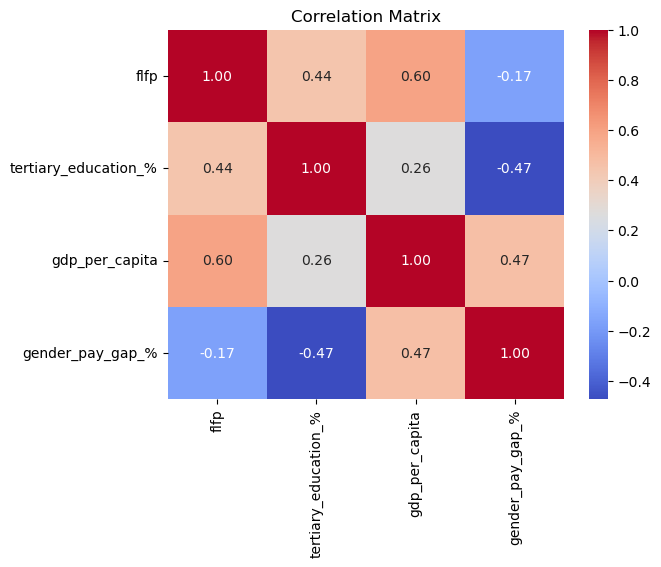

In [261]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

#### From this initial correlation matrix the following can be observed:
- FLFP vs Tertiary Education: There is a moderate positive correlation (0.44) suggesting that countries with higher proportion of women with tertiary education also tend to have higher FLFP. There might be other several factors that determine women's participation in the labor market, education being one of them.
- FLFP vs GDP per capita: There is a strong positive correlation (0.60) suggesting that countries with higher FLFP tend to have higher GDP per capita.
- FLFP vs Gender Pay Gap: There is a very weak correlation suggesting that higher FLFP is not strongly associated with a reduction of the gender pay gap. Therefore, women's increased participation in the labor market alone does not reduce the wage inequality.
#### Additional observations:
- Tertiary Education vs GDP per capita: There is a weak positive relationship suggesting that countries with more highly educated women tend to have somewhat higher GDP per capita.
- GDP per capita vs Gender Pay Gap: There is a moderate positive relationship suggesting that higher-income countries also tend to have larger gender pay gaps.
#### Summary:
The correlation matrix provides an initial overview of the relationships between the variables. The strongest positive association is observed between FLFP and GDP per capita (0.60), followed by tertiary education (0.44). Interestingly, FLFP shows only a very weak negative correlation with the gender pay gap (-0.17), suggesting that increased participation alone does not substantially reduce wage inequality.

#### Hypothesis 1: Female labor force participation (FLFP) has increased significantly over the last 20 years

In [262]:
#Average FLFP by year
flfp_by_year = (merged_df.groupby("year")["flfp"].mean())
flfp_by_year

year
2009    71.525
2010    72.350
2011    73.350
2012    74.025
2013    74.525
2014    74.800
2015    75.275
2016    75.700
2017    76.150
2018    76.550
2019    77.175
2020    76.550
2021    77.850
2022    78.675
2023    79.575
2024    79.825
Name: flfp, dtype: float64

In [263]:
#Average FLFP by country
flfp_by_country = (merged_df.groupby("country")["flfp"].mean().sort_values(ascending=False))
flfp_by_country

country
Netherlands    78.57500
Germany        76.36875
Portugal       75.46250
Spain          73.06875
Name: flfp, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

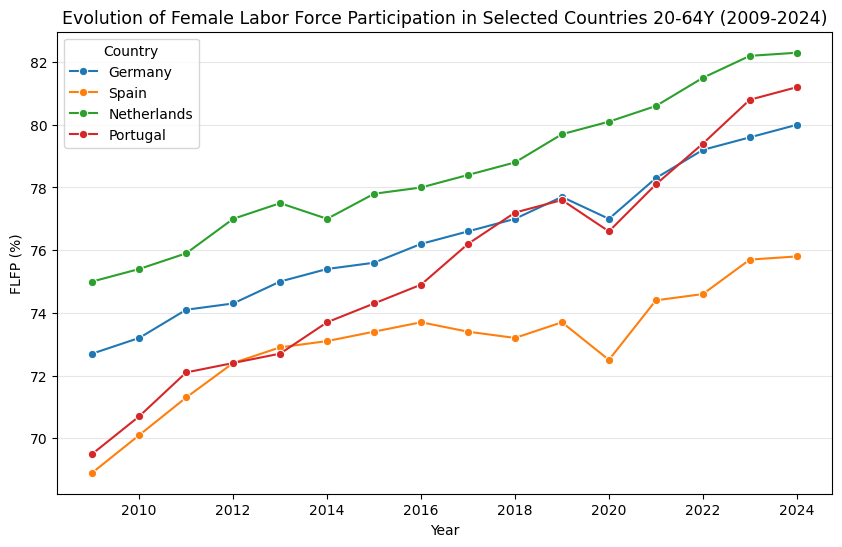

In [289]:
#Creating a lineplot with the evolution of FLFP per country
plt.figure(figsize=(10,6))

sns.lineplot(
    data=merged_df,
    x="year",
    y="flfp",
    hue="country",
    marker="o",
)

plt.title("Evolution of Female Labor Force Participation in Selected Countries 20-64Y (2009-2024)", fontsize=12.5)
plt.xlabel("Year")
plt.ylabel("FLFP (%)")
plt.grid(axis="y", alpha=0.3)

plt.legend(title="Country")
plt.show

In [278]:
#Creating a pivot table to illustrate the percentual change of FLFP per country in the period 2009-2024
change_flfp = (merged_df.pivot(
    index="country",
    columns="year",
    values="flfp"))

change_flfp["Increase (2009-2024)"] = change_flfp[2024] - change_flfp[2009]

change_flfp = change_flfp[["Increase (2009-2024)"]]

change_flfp = change_flfp.reset_index()

change_flfp = change_flfp.rename(columns={"country":"Country"})

change_flfp = change_flfp.sort_values(by="Increase (2009-2024)", ascending=False)

change_flfp.columns.name = None
change_flfp = change_flfp.reset_index(drop=True)

change_flfp

,Country,Increase (2009-2024)
0,Portugal,11.7
1,Germany,7.3
2,Netherlands,7.3
3,Spain,6.9


#### Interpretation:
- Historically, Spain has had lower FLFP rates compared to the other countries. While the Netherlands has had historically the highest FLFP rates across all four countries, Portugal has experienced the highest increase in the last 16 years, increasing 11.7 percentual points from 2009 to 2024, and Spain continues to have the lowest FLFP increase.

#### Hypothesis 2: Higher educational attainment among women is associated with higher labor force participation

In [279]:
#Average tertiary education by country
edu_by_country = (merged_df.groupby("country")["tertiary_education_%"].mean()).sort_values(ascending=False)
edu_by_country

country
Spain          38.796055
Netherlands    38.469814
Portugal       27.600735
Germany        26.797202
Name: tertiary_education_%, dtype: float64

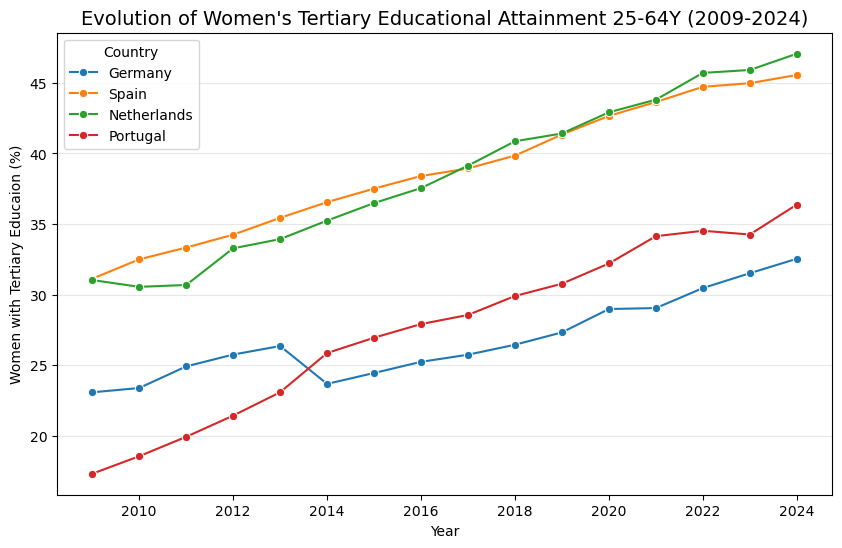

In [286]:
#Creating a line chart to show the evolution of tertiary education over time

plt.figure(figsize=(10,6))

sns.lineplot(
    data=merged_df,
    x="year",
    y="tertiary_education_%",
    hue="country",
    marker="o"
)

plt.title("Evolution of Women's Tertiary Educational Attainment 25-64Y (2009-2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Women with Tertiary Educaion (%)")

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Country")
plt.show()

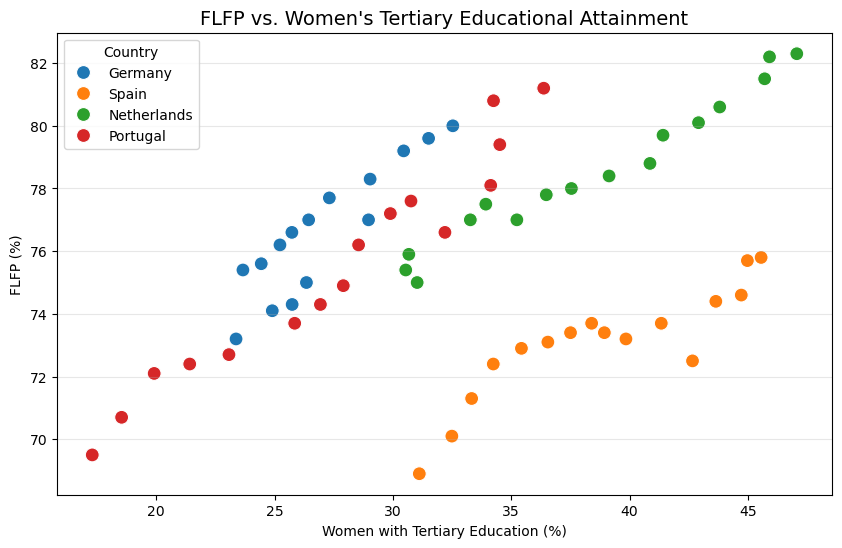

In [296]:
#Creating a scatter plot to show the relationship between tertiary education and FLFP
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x="tertiary_education_%",
    y="flfp",
    hue="country",
    s=100
)

plt.title("FLFP vs. Women's Tertiary Educational Attainment", fontsize=14)
plt.xlabel("Women with Tertiary Education (%)")
plt.ylabel("FLFP (%)")

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Country")

plt.show()

In [295]:
#Creating a pivot table to illustrate the percentual change of tertiary education per country in the period 2009-2024
change_edu = (merged_df.pivot(
    index="country",
    columns="year",
    values="tertiary_education_%"))

change_edu["Increase (2009-2024)"] = change_edu[2024] - change_edu[2009]

change_edu = change_edu[["Increase (2009-2024)"]]

change_edu = change_edu.reset_index()

change_edu = change_edu.rename(columns={"country":"Country"})

change_edu = change_edu.sort_values(by="Increase (2009-2024)", ascending=False)

change_edu.columns.name = None
change_edu = change_edu.reset_index(drop=True)

change_edu.round(1)

,Country,Increase (2009-2024)
0,Portugal,19.1
1,Netherlands,16.0
2,Spain,14.4
3,Germany,9.5


#### Interpretation:
- The line chart shows that women’s tertiary educational attainment increased in all four countries between 2009 and 2024. Spain and the Netherlands maintained the highest levels, while Portugal showed the strongest improvement from a much lower starting point. Germany increased more gradually and remained the country with the lowest tertiary education share among women, which may partly reflect its strong vocational education and apprenticeship system.
- The scatter plot suggests that as women's tertiary educational attainment increases, FLFP also tends to increase. This is supported by the correlation coefficient of 0.44, indicating a moderate positive relationship. However, the moderate strength of the relationship suggests that education is only one of several factors influencing women's participation in the labor market, especially in the case of Spain, where higher tertiary educational attainment does not translate into a higher FLFP in the same trend as the other countries.

#### Hypothesis 3: Higher FLFP is associated with higher levels of economic development, measured by GDP per capita

In [297]:
#Average GDP per capita by country
gdp_by_country = (merged_df.groupby("country")["gdp_per_capita"].mean().sort_values(ascending=False))
gdp_by_country

country
Netherlands    54315.821688
Germany        47595.025766
Spain          30052.342927
Portugal       23091.096322
Name: gdp_per_capita, dtype: float64

In [306]:
#Compare average GDP with average FLFP
summary_gdp = (merged_df.groupby("country").agg({
        "flfp": "mean",
        "gdp_per_capita": "mean"
    }).sort_values(by="flfp", ascending=False)
    .round(2)
)

summary_gdp = summary_gdp.reset_index()

summary_gdp = summary_gdp.rename(columns={"country":"Country", "flfp":"Avg FLFP", "gdp_per_capita":"Avg GDP per capita"})

summary_gdp

,Country,Avg FLFP,Avg GDP per capita
0,Netherlands,78.58,54315.82
1,Germany,76.37,47595.03
2,Portugal,75.46,23091.10
3,Spain,73.07,30052.34


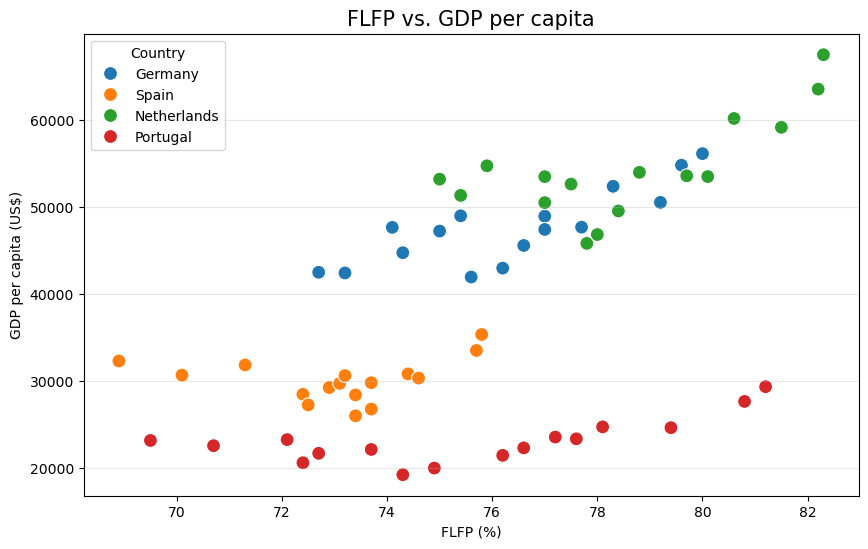

In [309]:
#Creating a scatter plot to show the relationship between GDP per capita and FLFP
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x="flfp",
    y="gdp_per_capita",
    hue="country",
    s=100
)

plt.title("FLFP vs. GDP per capita", fontsize=15)
plt.xlabel("FLFP (%)")
plt.ylabel("GDP per capita (US$)")

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Country")

plt.show()

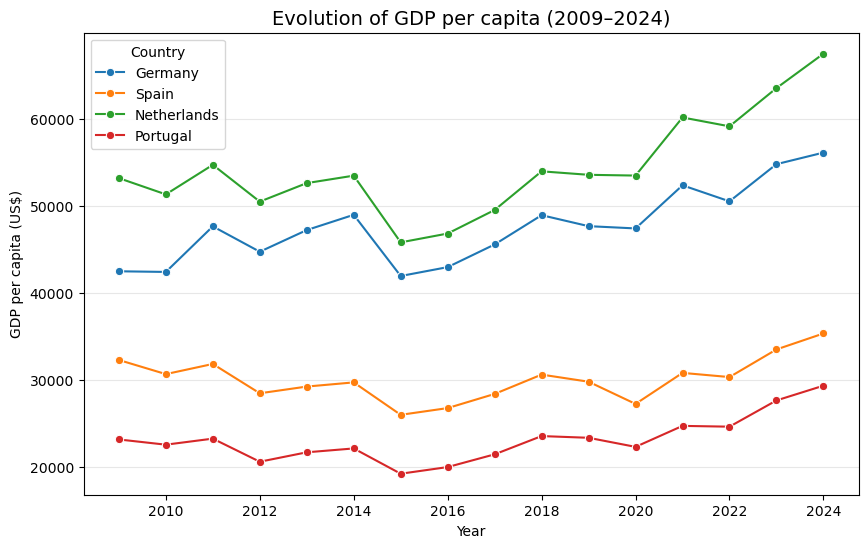

In [316]:
#Creating a line chart with GDP per capita over time per country
plt.figure(figsize=(10,6))

sns.lineplot(
    data=merged_df,
    x="year",
    y="gdp_per_capita",
    hue="country",
    marker="o"
)

plt.title("Evolution of GDP per capita (2009–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("GDP per capita (US$)")

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Country")

plt.show()

#### Interpretation:
- The scatter plot shows a clear positive relationship between FLFP and GDP per capita. Country-year observations with higher FLFP are associated with higher GDP per capita. The correlation coefficient of 0.60 indicates a strong positive association, supporting the hypothesis that economies with greater female participation in the labor market also tend to exhibit higher levels of economic output per person.

#### Hypothesis 4: Despite higher FLFP, a substantial gender pay gap persists across the four countries

In [314]:
#Average gender pay gap by country
paygap_by_country = (merged_df.groupby("country")["gender_pay_gap_%"].mean().sort_values(ascending=False))

paygap_by_country

country
Germany        20.2375
Netherlands    15.6500
Spain          13.0125
Portugal       10.9500
Name: gender_pay_gap_%, dtype: float64

In [315]:
#Compare average gender pay gap with average FLFP
summary_paygap = (merged_df.groupby("country").agg({
        "flfp": "mean",
        "gender_pay_gap_%": "mean"
    }).sort_values(by="flfp", ascending=False)
    .round(2)
)

summary_paygap = summary_paygap.reset_index()

summary_paygap = summary_paygap.rename(columns={"country":"Country", "flfp":"Avg FLFP", "gender_pay_gap_%":"Avg Gender Pay Gap"})

summary_paygap

,Country,Avg FLFP,Avg Gender Pay Gap
0,Netherlands,78.58,15.65
1,Germany,76.37,20.24
2,Portugal,75.46,10.95
3,Spain,73.07,13.01


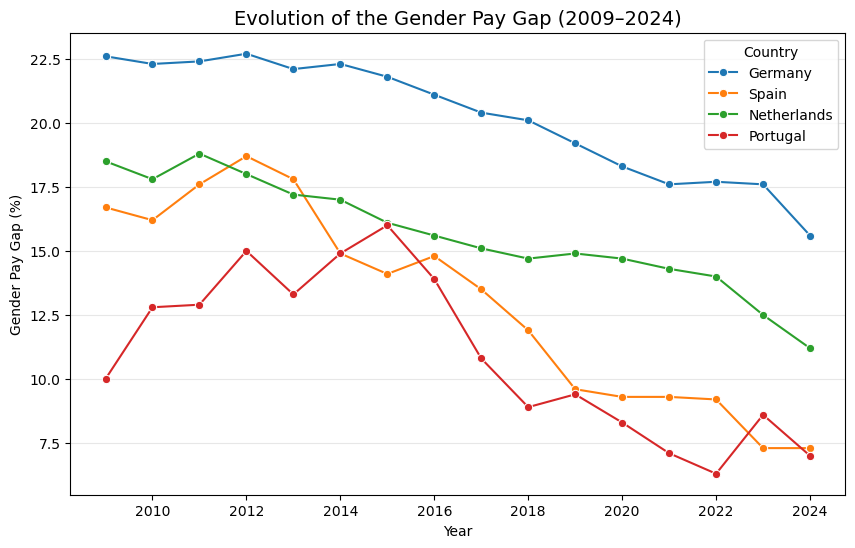

In [317]:
#Creating a line chart with gender pay gap over time per country
plt.figure(figsize=(10,6))

sns.lineplot(
    data=merged_df,
    x="year",
    y="gender_pay_gap_%",
    hue="country",
    marker="o"
)

plt.title("Evolution of the Gender Pay Gap (2009–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Gender Pay Gap (%)")

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Country")

plt.show()

In [319]:
#Creating a pivot table to illustrate the percentual gender pay gap reduction per country in the period 2009-2024
change_paygap = (merged_df.pivot(
    index="country",
    columns="year",
    values="gender_pay_gap_%"))

change_paygap["Reduction (2009-2024)"] = change_paygap[2009] - change_paygap[2024]

change_paygap = change_paygap[["Reduction (2009-2024)"]]

change_paygap = change_paygap.reset_index()

change_paygap = change_paygap.rename(columns={"country":"Country"})

change_paygap = change_paygap.sort_values(by="Reduction (2009-2024)", ascending=False)

change_paygap.columns.name = None
change_paygap = change_paygap.reset_index(drop=True)

change_paygap.round(1)

,Country,Reduction (2009-2024)
0,Spain,9.4
1,Netherlands,7.3
2,Germany,7.0
3,Portugal,3.0


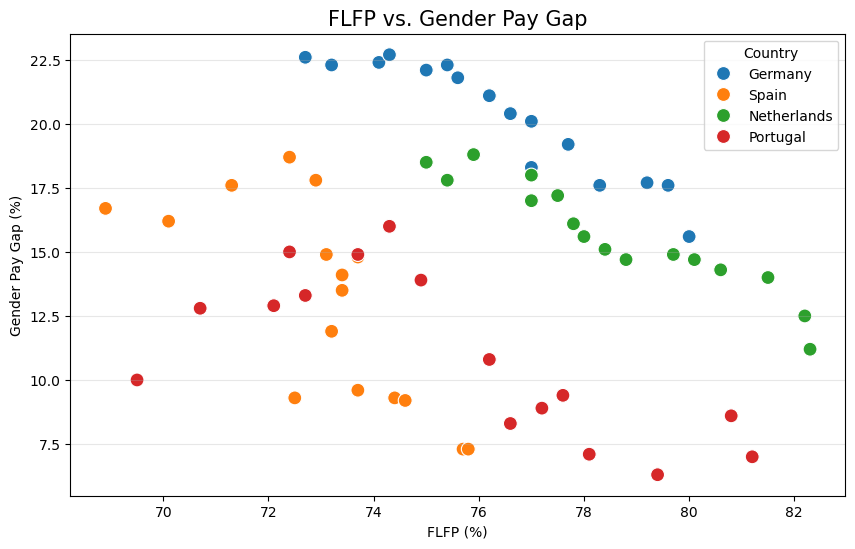

In [320]:
#Creating a scatter plot to show the relationship between Gender Pay Gap and FLFP
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x="flfp",
    y="gender_pay_gap_%",
    hue="country",
    s=100
)

plt.title("FLFP vs. Gender Pay Gap", fontsize=15)
plt.xlabel("FLFP (%)")
plt.ylabel("Gender Pay Gap (%)")

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Country")

plt.show()

In [334]:
#Creaing a summary table with the evolution of part-time employment by sex per country
parttime_summary = (
    part_time_clean[
        part_time_clean["year"].isin([2009, 2024])
    ]
    .pivot_table(
        index="country",
        columns=["year", "sex"],
        values="part-time_employment_%"
    )
)

In [335]:
country_mapping = {
    "DE": "Germany",
    "ES": "Spain",
    "NL": "Netherlands",
    "PT": "Portugal"
}

parttime_summary = parttime_summary.rename(index=country_mapping)

In [336]:
parttime_summary = parttime_summary.rename(
    columns={
        "Female": "Women",
        "Male": "Men"
    },
    level=1
)

In [338]:
parttime_summary.index.name = "Country"
parttime_summary.columns.names = [None, None]
parttime_summary.index.name = None
parttime_summary

2009        2024      
            Women   Men Women   Men
Germany      45.5   8.3  48.3  11.3
Spain        22.0   4.4  20.9   6.1
Netherlands  73.6  19.3  61.2  18.7
Portugal     13.0   4.2   9.5   4.6

In [339]:
parttime_summary[(2009, "Difference")] = (
    parttime_summary[(2009, "Women")] -
    parttime_summary[(2009, "Men")]
)

parttime_summary[(2024, "Difference")] = (
    parttime_summary[(2024, "Women")] -
    parttime_summary[(2024, "Men")]
)

In [340]:
parttime_summary = parttime_summary[
    [
        (2009, "Women"),
        (2009, "Men"),
        (2009, "Difference"),
        (2024, "Women"),
        (2024, "Men"),
        (2024, "Difference")
    ]
]

parttime_summary = parttime_summary.round(1)
parttime_summary

2009                   2024                 
            Women   Men Difference Women   Men Difference
Germany      45.5   8.3       37.2  48.3  11.3       37.0
Spain        22.0   4.4       17.6  20.9   6.1       14.8
Netherlands  73.6  19.3       54.3  61.2  18.7       42.5
Portugal     13.0   4.2        8.8   9.5   4.6        4.9

#### Interpretation:
- The scatter plot reveals a weak negative relationship between FLFP and the gender pay gap. This suggests that increasing women's participation in the labor market alone is insufficient to eliminate wage inequality, and that additional structural factors likely contribute to persistent gender pay disparities.
- While FLFP increased substantially over the study period, this improvement was not accompanied by an equally strong reduction in the gender pay gap.
- Women have substantially higher part-time employment rates than men in all four countries, both in 2009 and 2024.
- In Germany, women are approximately four times more likely to work part-time than men. Interestingly, both women and men have slightly increased their part-time employment over time.
- Spain has lower part-time employment overall. Women's rate has decreased slightly and men's has slighly increased.
- The Netherlands has the highest female part-time employment (most women have part-time jobs) and its difference to male part-time employment is large.
- In Portugal, part-time is very uncommon for both women and men and women's rate has decreased over the years.

#### Summary:
While FLFP increased across all four countries, women consistently had substantially higher part-time employment rates than men throughout the study period. This difference was particularly pronounced in the Netherlands and Germany, where almost half or more of employed women worked part-time in 2024. Since part-time employment is often associated with fewer working hours, reduced career progression opportunities, and lower lifetime earnings, these patterns may help explain why higher female labor force participation has not been accompanied by an equally large reduction in the gender pay gap.

### Conclusions